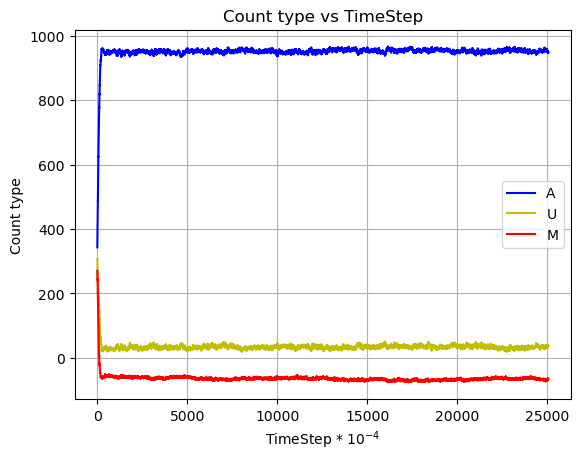

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the .dat file into a pandas DataFrame
df = pd.read_csv('types1.dat', comment='#', names=['A', 'U','M',"Swi6","Swi6M"])

# Plot c_R2[0] against TimeStep
plt.plot( df['A'], label ='A', color = 'b')
plt.plot( df['U'], label ='U', color = 'y')
plt.plot( df['M'] - 80, label ='M', color = 'r')
plt.legend()
plt.xlabel('TimeStep * $10^{-4}$')
plt.ylabel('Count type')
plt.title('Count type vs TimeStep')
plt.grid(True)
#plt.show()
plt.savefig("CountTypeLongChromatin.pdf")


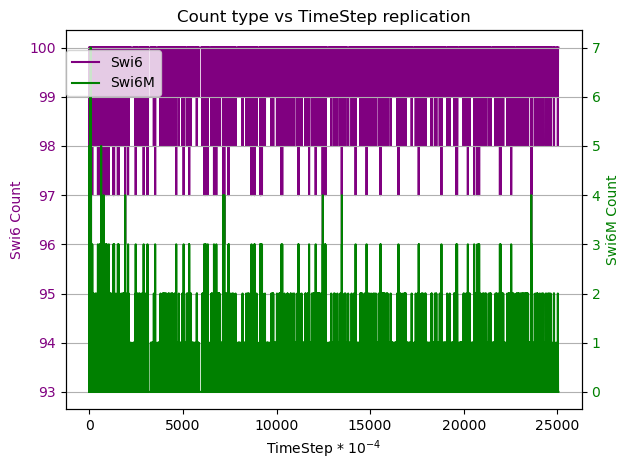

In [2]:
fig, ax1 = plt.subplots()

ax1.plot( df['Swi6'], label='Swi6', color='purple')
ax1.set_xlabel('TimeStep * $10^{-4}$')
ax1.set_ylabel('Swi6 Count', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot( df['Swi6M'], label='Swi6M', color='green')
ax2.set_ylabel('Swi6M Count', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Adding title and grid
plt.title('Count type vs TimeStep replication')
fig.tight_layout()  # Adjust layout to prevent clipping

# Display legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.grid(True)
plt.show()

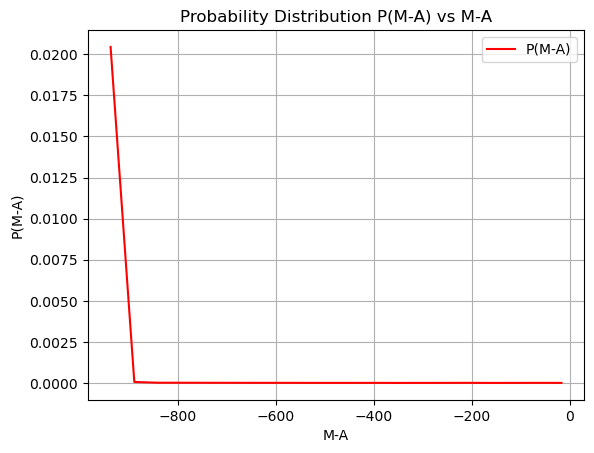

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# Calculate the histogram of 'M -A'
hist, bin_edges = np.histogram(df['M'] - df['A'], bins=20, density=True)  # You can adjust the number of bins

# The mid points of the bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot P(M) against M
plt.plot(bin_centers, hist, label='P(M-A)', color='r')
plt.legend()
plt.xlabel('M-A')
plt.ylabel('P(M-A)')
plt.title('Probability Distribution P(M-A) vs M-A')
plt.grid(True)
plt.show()


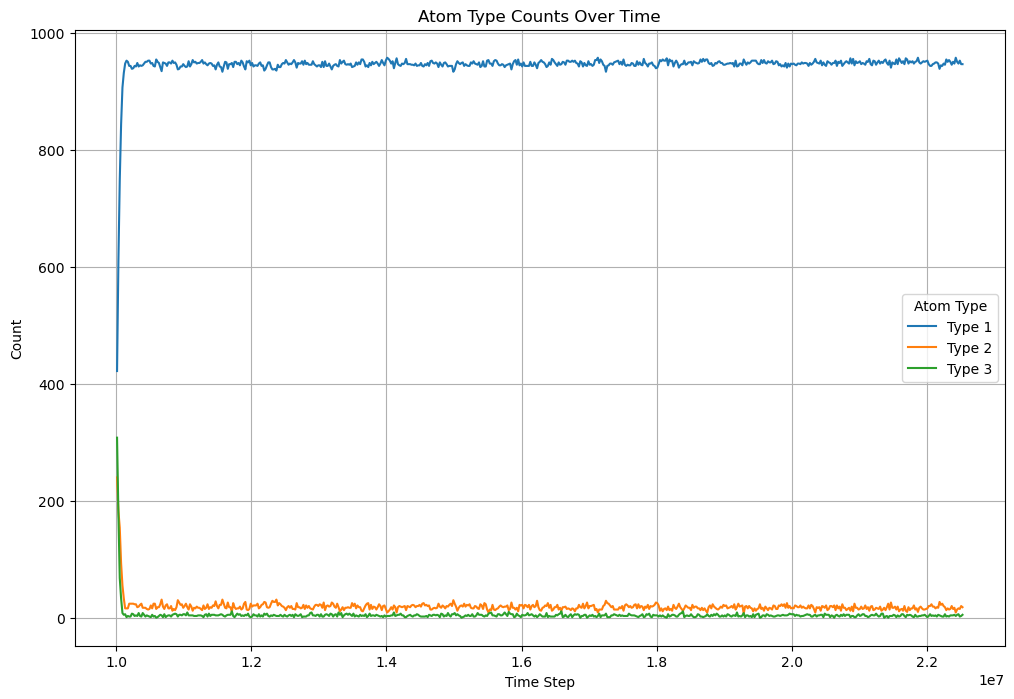

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the path to the data file
file_path = 'deltaK_types.dat'

def parse_lammps_dump(file_path):
    time_steps = []
    type_counts = []

    with open(file_path, 'r') as file:
        line = file.readline().strip()
        
        while line:
            if line.startswith('ITEM: TIMESTEP'):
                time_step = int(file.readline().strip())
                time_steps.append(time_step)
                
                # Skip lines until 'ITEM: ATOMS'
                while True:
                    line = file.readline().strip()
                    if line.startswith('ITEM: ATOMS'):
                        break
                
                # Read atom data
                atom_data = []
                while True:
                    line = file.readline().strip()
                    if not line or line.startswith('ITEM:') or line.startswith('BOX'):
                        break
                    parts = line.split()
                    if len(parts) >= 2:
                        try:
                            atom_id = int(parts[0])
                            atom_type = int(parts[1])
                            atom_data.append([atom_id, atom_type])
                        except ValueError:
                            print(f"Skipping line due to conversion error: {line}")

                # Convert to DataFrame and count atom types
                df = pd.DataFrame(atom_data, columns=['id', 'type'])
                type_count = df['type'].value_counts()
                type_counts.append(type_count)
            
            line = file.readline().strip()

    # Ensure all type counts are aligned by filling missing types with zeros
    all_types = set()
    for count in type_counts:
        all_types.update(count.index)

    type_counts_df = pd.DataFrame([{t: count.get(t, 0) for t in all_types} for count in type_counts])
    type_counts_df.index = time_steps
    type_counts_df.sort_index(inplace=True)
    
    return time_steps, type_counts_df

# Parse the file and load data
try:
    time_steps, type_counts_df = parse_lammps_dump(file_path)
except Exception as e:
    print(f"An error occurred: {e}")
    exit()

# Plot the type counts as a function of time
plt.figure(figsize=(12, 8))
for atom_type in type_counts_df.columns:
    plt.plot(type_counts_df.index, type_counts_df[atom_type], label=f'Type {atom_type}')

plt.xlabel('Time Step')
plt.ylabel('Count')
plt.title('Atom Type Counts Over Time')
plt.legend(title='Atom Type')
plt.grid(True)
plt.show()
